In [16]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA_PATH = Path("data/Q1b_NER.csv")
OUT_DIR = Path("outputs")
OUT_DIR.mkdir(exist_ok=True)

SEED = 2026
N_SETS = 10
MULTIPLIER = 10
SAVE_RANDOM_CUISINES = False

ORIG_COLOR, RAND_COLOR = "#2a78d6", "#eb6834"
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 200, "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False})

In [17]:
def load_recipes(path):
    raw = pd.read_csv(path)
    missing_cols = {"Recipe_ID", "Ingredient_Name"} - set(raw.columns)
    if missing_cols:
        raise ValueError(f"Missing columns in {path}: {missing_cols}")
    df = raw[["Recipe_ID", "Ingredient_Name"]].dropna().copy()
    df["Ingredient_Name"] = df["Ingredient_Name"].astype(str).str.strip().str.lower()
    df = df[df["Ingredient_Name"] != ""]
    recipes = (df.groupby("Recipe_ID", sort=True)["Ingredient_Name"]
                 .agg(lambda s: tuple(sorted(set(s)))))
    return recipes[recipes.map(len) > 0]


recipes = load_recipes(DATA_PATH)
recipe_ids = recipes.index.to_numpy()
orig_sizes = recipes.map(len).to_numpy()
ingredients = np.array(sorted({i for r in recipes for i in r}))
N, U = len(recipes), len(ingredients)

print(f"Recipes (N)            : {N:,}")
print(f"Unique ingredients (U) : {U:,}")
print(f"Recipe size  min/mean/max : {orig_sizes.min()} / {orig_sizes.mean():.2f} / {orig_sizes.max()}")
assert orig_sizes.max() <= U

Recipes (N)            : 9,988
Unique ingredients (U) : 12,641
Recipe size  min/mean/max : 1 / 10.00 / 33


In [18]:
def size_counts(sizes, support):
    """Number of recipes of each size in `support` (zeros included)."""
    return pd.Series(sizes).value_counts().reindex(support, fill_value=0).to_numpy()


size_support = np.arange(1, orig_sizes.max() + 1)
orig_counts = size_counts(orig_sizes, size_support)


def style_size_axis(ax):
    ax.set_xticks(size_support[::2])
    ax.set_xticks(size_support, minor=True)
    ax.set_xlim(0.3, size_support.max() + 0.7)
    ax.grid(axis="y", alpha=0.3)

In [19]:
def replica_cuisine(sizes, n_ingredients, rng):
    """One random recipe (array of ingredient indices) per original recipe, same size."""
    return [rng.choice(n_ingredients, size=s, replace=False) for s in sizes]


child_seeds = np.random.SeedSequence(SEED).spawn(N_SETS)
random_sets = [replica_cuisine(orig_sizes, U, np.random.default_rng(s)) for s in child_seeds]
print(f"Generated {len(random_sets)} random cuisines with {len(random_sets[0]):,} recipes each")

for rid, orig, rnd in list(zip(recipe_ids, recipes, random_sets[0]))[:3]:
    print(f"\n{rid} (size {len(orig)})\n  original: {', '.join(orig)}\n  replica : {', '.join(ingredients[rnd])}")

Generated 10 random cuisines with 9,988 recipes each

Recipe 1 (size 7)
  original: basil leaves, buffalo mozzarella, chopped tomatoes, fresh pesto, frozen pizza dough, glug of olive oil, pork sausages
  replica : light spelt flour, penne or fusilli, chunky skinless  white fish fillets, golden rum, vegan dark chocolate, lean beef steak, active white  sourdough starter

Recipe 10 (size 5)
  original: 0% fat probiotic plain yogurt, banana, blueberries, porridge oat, toasted flaked almonds
  replica : persimmons, white sugar, a little sesame oil, venison steaks, corn cobs cooked rice and tortilla wraps

Recipe 100 (size 11)
  original: apples, caster sugar, custard powder, egg yolk, egg yolks, icing sugar, lemon, plain flour, unsalted butter, vanilla paste, whole milk
  replica : soya milk, organic sultanas, beef fillet, spinach half cooked each, thick natural yogurt, veg or sunflower oil, mild or madras  curry paste, pomegranate seeds and salad leaves, pitted olives of your choice, cranb

In [20]:
orig_sets = [set(r) for r in recipes]
ing_index = {name: j for j, name in enumerate(ingredients)}
orig_idx_sets = [{ing_index[i] for i in r} for r in recipes]

for k, cuisine in enumerate(random_sets, start=1):
    assert len(cuisine) == N
    rand_sizes = np.array([len(r) for r in cuisine])
    assert np.array_equal(rand_sizes, orig_sizes)
    assert all(len(set(r.tolist())) == len(r) for r in cuisine)
    assert all(0 <= r.min() and r.max() < U for r in cuisine)

again = replica_cuisine(orig_sizes, U, np.random.default_rng(child_seeds[0]))
assert all(np.array_equal(a, b) for a, b in zip(again, random_sets[0]))

overlap = np.mean([len(orig_idx_sets[i] & set(random_sets[0][i].tolist())) / orig_sizes[i] for i in range(N)])
identical = sum(orig_idx_sets[i] == set(random_sets[0][i].tolist()) for i in range(N))
print("All 10 sets: correct recipe count, exact per-recipe sizes, no duplicate ingredients, reproducible.")
print(f"Set 1: mean fraction of a recipe's ingredients kept from its original = {overlap:.5f}; "
      f"replicas identical to original = {identical}")

All 10 sets: correct recipe count, exact per-recipe sizes, no duplicate ingredients, reproducible.
Set 1: mean fraction of a recipe's ingredients kept from its original = 0.00075; replicas identical to original = 0


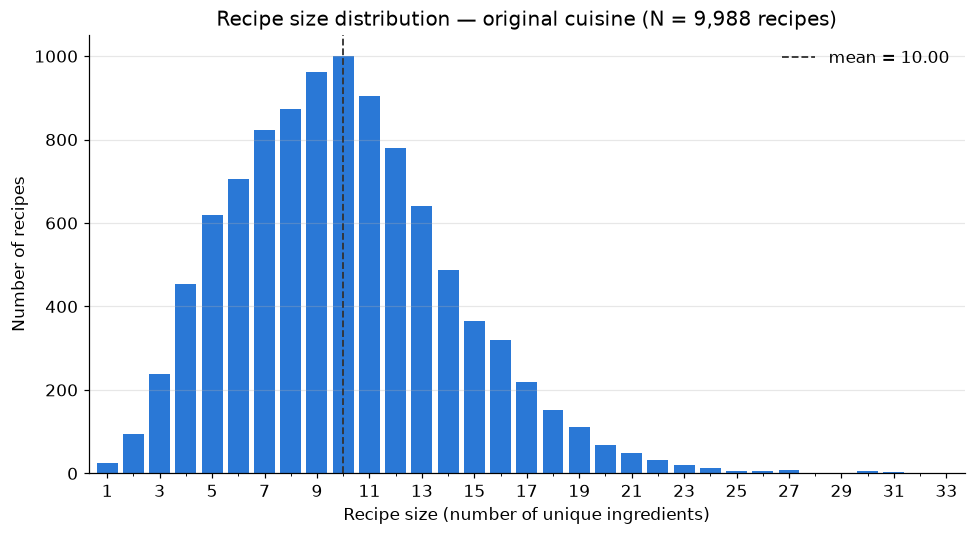

In [21]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(size_support, orig_counts, width=0.8, color=ORIG_COLOR)
ax.axvline(orig_sizes.mean(), color="#333333", ls="--", lw=1.2, label=f"mean = {orig_sizes.mean():.2f}")
ax.set_xlabel("Recipe size (number of unique ingredients)")
ax.set_ylabel("Number of recipes")
ax.set_title(f"Recipe size distribution — original cuisine (N = {N:,} recipes)")
style_size_axis(ax)
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(OUT_DIR / "Q2a_original_recipe_size_distribution.png")
plt.show()

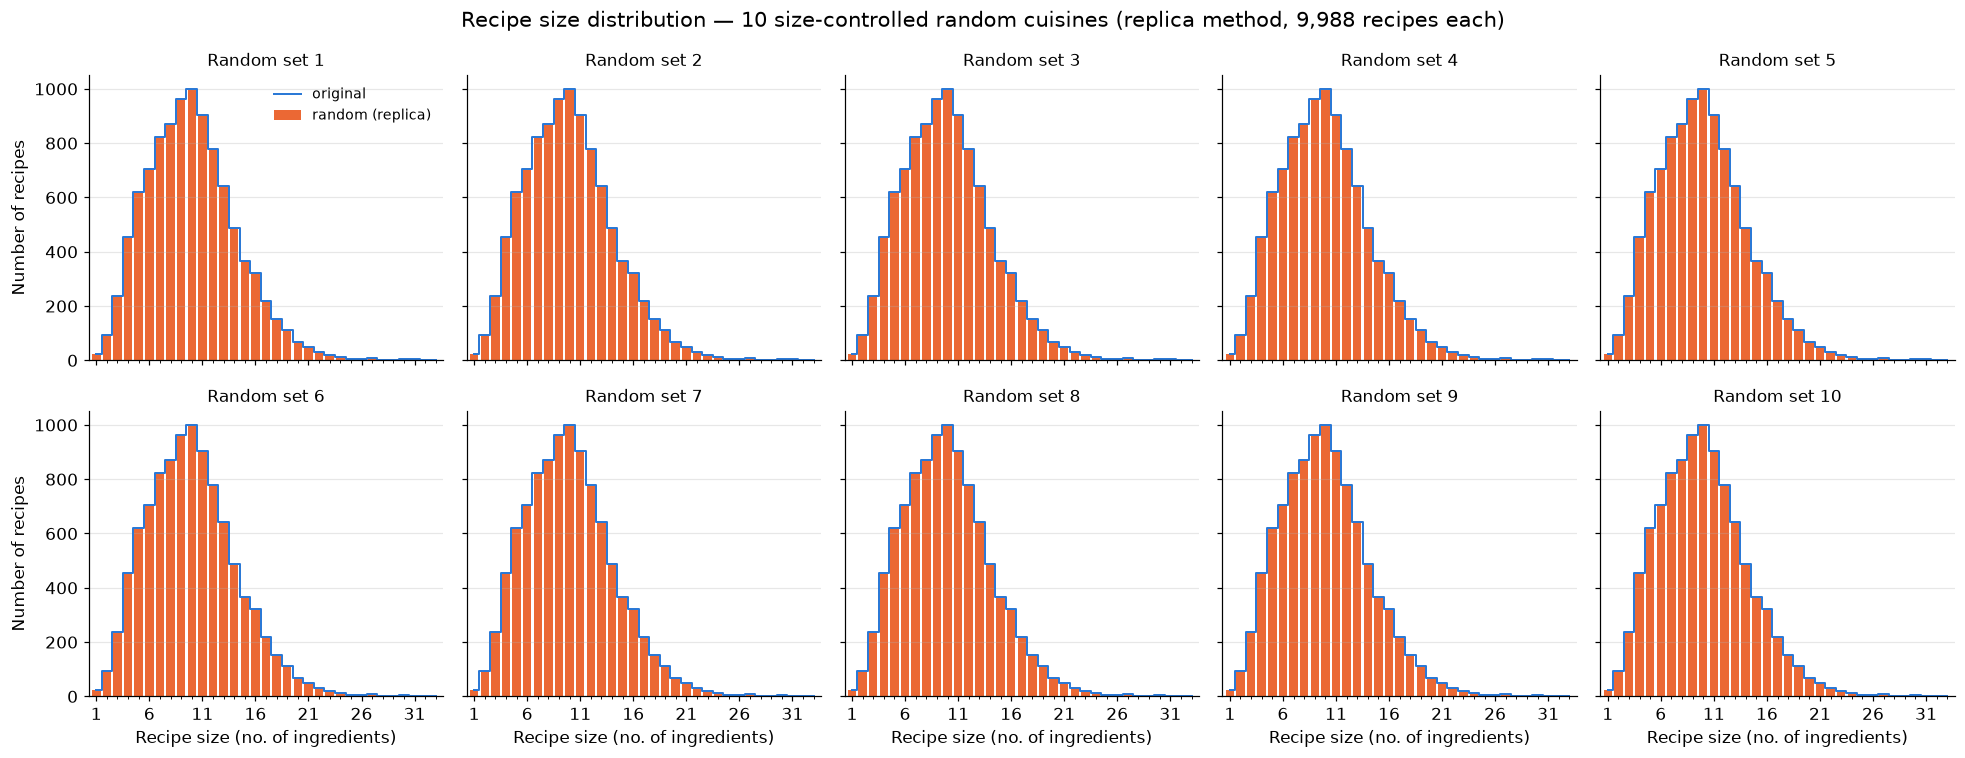

In [22]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7), sharex=True, sharey=True)
for k, (ax, cuisine) in enumerate(zip(axes.flat, random_sets), start=1):
    rc = size_counts([len(r) for r in cuisine], size_support)
    ax.bar(size_support, rc, width=0.8, color=RAND_COLOR, label="random (replica)")
    ax.step(size_support, orig_counts, where="mid", color=ORIG_COLOR, lw=1.3, label="original")
    ax.set_title(f"Random set {k}", fontsize=11)
    style_size_axis(ax)
    ax.set_xticks(size_support[::5])
for ax in axes[1]:
    ax.set_xlabel("Recipe size (no. of ingredients)")
for ax in axes[:, 0]:
    ax.set_ylabel("Number of recipes")
axes[0, 0].legend(frameon=False, fontsize=9)
fig.suptitle(f"Recipe size distribution — 10 size-controlled random cuisines (replica method, {N:,} recipes each)",
             fontsize=14)
fig.tight_layout()
fig.savefig(OUT_DIR / "Q2a_random_recipe_size_distribution.png")
plt.show()

In [23]:
counts_table = pd.DataFrame({"Recipe_Size": size_support, "Original": orig_counts})
for k, cuisine in enumerate(random_sets, start=1):
    counts_table[f"Random_Set_{k}"] = size_counts([len(r) for r in cuisine], size_support)
counts_table.to_csv(OUT_DIR / "Q2a_recipe_size_counts.csv", index=False)

if SAVE_RANDOM_CUISINES:
    rows = [(k, rid, name) for k, cuisine in enumerate(random_sets, start=1)
            for rid, r in zip(recipe_ids, cuisine) for name in ingredients[r]]
    pd.DataFrame(rows, columns=["Set", "Original_Recipe_ID", "Ingredient_Name"]) \
      .to_csv(OUT_DIR / "Q2a_random_cuisines.csv", index=False)
counts_table.head()

,Recipe_Size,Original,Random_Set_1,Random_Set_2,Random_Set_3,Random_Set_4,Random_Set_5,Random_Set_6,Random_Set_7,Random_Set_8,Random_Set_9,Random_Set_10
0,1,24,24,24,24,24,24,24,24,24,24,24
1,2,94,94,94,94,94,94,94,94,94,94,94
2,3,238,238,238,238,238,238,238,238,238,238,238
3,4,454,454,454,454,454,454,454,454,454,454,454
4,5,620,620,620,620,620,620,620,620,620,620,620


## 3. Q2(b) — Size-controlled cuisine by inverse transformation

The replica method copies the size of each recipe. Inverse transformation instead treats recipe size as a **random variable S** and **samples** new sizes from the original distribution. This lets us generate a cuisine of any size, here **10 × N = 99,880 recipes**.

**Step 1 — Probability mass function (PMF)** estimated from the original cuisine:
$$p(s) = P(S = s) = \frac{n_s}{N}, \qquad \sum_s p(s) = 1$$
where n_s is the number of original recipes with s ingredients.

**Step 2 — Cumulative distribution function (CDF):**
$$F(s) = P(S \le s) = \sum_{t \le s} p(t), \qquad F(s_{\max}) = 1$$

**Step 3 — Inverse transformation.** Draw u ~ Uniform(0, 1) and return
$$S = F^{-1}(u) = \min\{\, s : F(s) \ge u \,\}.$$
*Why this works:* S = s exactly when F(s−1) < u ≤ F(s). That interval has length F(s) − F(s−1) = p(s), so P(S = s) = p(s). Uniform random numbers become recipe sizes with the original distribution. Because F is a non-decreasing step function, the minimum is found with a binary search over the CDF (`np.searchsorted`).

**Step 4 — Fill the recipe.** Recipe size and ingredient choice are separate steps. Once S is drawn, the recipe gets S distinct ingredients drawn uniformly from the universe, as in Q2(a).

**Edge cases handled:**
* The PMF is built only over **observed** sizes. In our data every size from 1 to 33 occurs at least once, so no size has zero probability. With other data, a missing size would have p = 0, F would be flat there, and `min{s : F(s) ≥ u}` would never return it. Sizes below 1 or above the maximum can never be generated.
* Floating-point rounding could leave F(s_max) = 0.9999999…, so the last CDF value is set to exactly 1.0.
* `rng.random()` returns u in [0, 1). A draw of u = 0 maps to the smallest observed size, which is valid.

In [24]:
size_values, size_freq = np.unique(orig_sizes, return_counts=True)
pmf = size_freq / size_freq.sum()

cdf = np.cumsum(pmf)
cdf[-1] = 1.0


def inverse_cdf(u):
    """F^{-1}(u) = smallest recipe size s with F(s) >= u (vectorised binary search)."""
    return size_values[np.searchsorted(cdf, u, side="left")]


assert np.isclose(pmf.sum(), 1.0)
assert np.all(np.diff(cdf) >= 0) and cdf[-1] == 1.0
print(pd.DataFrame({"size s": size_values, "n_s": size_freq,
                    "p(s)": pmf.round(5), "F(s)": cdf.round(5)}).to_string(index=False))

 size s  n_s    p(s)    F(s)
      1   24 0.00240 0.00240
      2   94 0.00941 0.01181
      3  238 0.02383 0.03564
      4  454 0.04545 0.08110
      5  620 0.06207 0.14317
      6  705 0.07058 0.21376
      7  824 0.08250 0.29626
      8  872 0.08730 0.38356
      9  963 0.09642 0.47998
     10 1001 0.10022 0.58020
     11  904 0.09051 0.67070
     12  780 0.07809 0.74880
     13  641 0.06418 0.81298
     14  487 0.04876 0.86173
     15  366 0.03664 0.89838
     16  320 0.03204 0.93042
     17  218 0.02183 0.95224
     18  153 0.01532 0.96756
     19  111 0.01111 0.97867
     20   67 0.00671 0.98538
     21   49 0.00491 0.99029
     22   32 0.00320 0.99349
     23   20 0.00200 0.99549
     24   12 0.00120 0.99670
     25    5 0.00050 0.99720
     26    6 0.00060 0.99780
     27    7 0.00070 0.99850
     28    1 0.00010 0.99860
     29    2 0.00020 0.99880
     30    6 0.00060 0.99940
     31    3 0.00030 0.99970
     32    2 0.00020 0.99990
     33    1 0.00010 1.00000


In [25]:
N_GEN = MULTIPLIER * N
rng_b = np.random.default_rng(np.random.SeedSequence(SEED).spawn(N_SETS + 1)[-1])

u = rng_b.random(N_GEN)
gen_sizes = inverse_cdf(u)
gen_recipes = [rng_b.choice(U, size=s, replace=False) for s in gen_sizes]

print(f"Generated {len(gen_recipes):,} recipes (= {MULTIPLIER} x {N:,})")
print(f"Generated size min/mean/max: {gen_sizes.min()} / {gen_sizes.mean():.3f} / {gen_sizes.max()}")
print(f"Original  size min/mean/max: {orig_sizes.min()} / {orig_sizes.mean():.3f} / {orig_sizes.max()}")

Generated 99,880 recipes (= 10 x 9,988)
Generated size min/mean/max: 1 / 10.017 / 33
Original  size min/mean/max: 1 / 9.999 / 33


In [26]:
assert len(gen_recipes) == N_GEN
assert np.isin(gen_sizes, size_values).all()
assert all(len(r) == s for r, s in zip(gen_recipes, gen_sizes))
assert all(len(set(r.tolist())) == len(r) for r in gen_recipes)

rng_check = np.random.default_rng(np.random.SeedSequence(SEED).spawn(N_SETS + 1)[-1])
assert np.array_equal(inverse_cdf(rng_check.random(N_GEN)), gen_sizes)

orig_pmf_full = orig_counts / N
gen_counts = size_counts(gen_sizes, size_support)
gen_pmf_full = gen_counts / N_GEN
tvd = 0.5 * np.abs(gen_pmf_full - orig_pmf_full).sum()
ks = np.abs(np.cumsum(gen_pmf_full) - np.cumsum(orig_pmf_full)).max()
print(f"Total variation distance (generated vs original): {tvd:.4f}")
print(f"KS statistic D = max |F_gen - F_orig|            : {ks:.4f}")
print(f"Mean size: original {orig_sizes.mean():.3f}, generated {gen_sizes.mean():.3f}; "
      f"SD: original {orig_sizes.std():.3f}, generated {gen_sizes.std():.3f}")

Total variation distance (generated vs original): 0.0084
KS statistic D = max |F_gen - F_orig|            : 0.0030
Mean size: original 9.999, generated 10.017; SD: original 4.201, generated 4.227


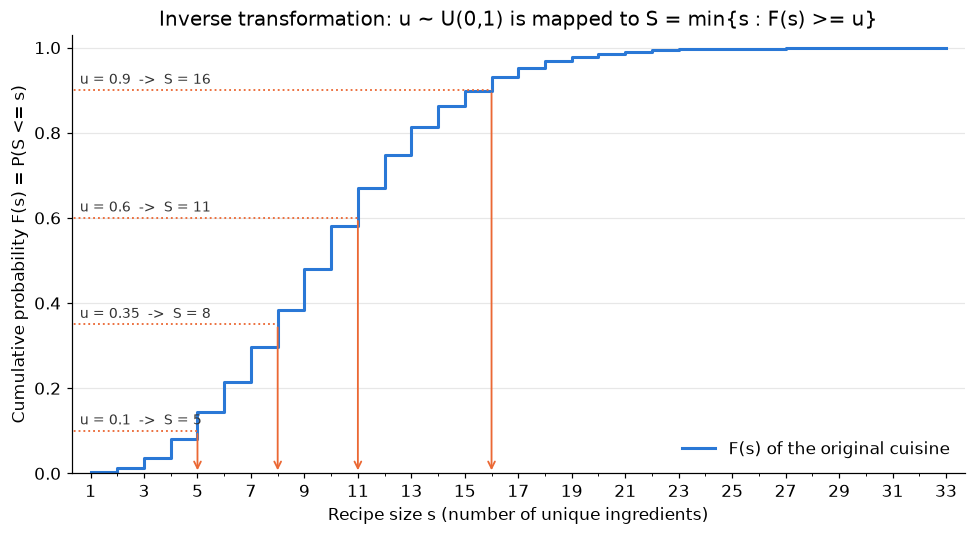

In [27]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.step(size_values, cdf, where="post", color=ORIG_COLOR, lw=2, label="F(s) of the original cuisine")
for uu in [0.1, 0.35, 0.6, 0.9]:
    s = inverse_cdf(np.array([uu]))[0]
    ax.annotate("", xy=(s, 0), xytext=(s, uu), arrowprops=dict(arrowstyle="->", color=RAND_COLOR, lw=1.2))
    ax.plot([0, s], [uu, uu], color=RAND_COLOR, lw=1.2, ls=":")
    ax.text(0.6, uu + 0.015, f"u = {uu}  ->  S = {s}", fontsize=9, color="#333333")
ax.set_xlabel("Recipe size s (number of unique ingredients)")
ax.set_ylabel("Cumulative probability F(s) = P(S <= s)")
ax.set_title("Inverse transformation: u ~ U(0,1) is mapped to S = min{s : F(s) >= u}")
ax.set_ylim(0, 1.03)
style_size_axis(ax)
ax.legend(frameon=False, loc="lower right")
fig.tight_layout()
fig.savefig(OUT_DIR / "Q2b_cdf_inverse_transformation.png")
plt.show()

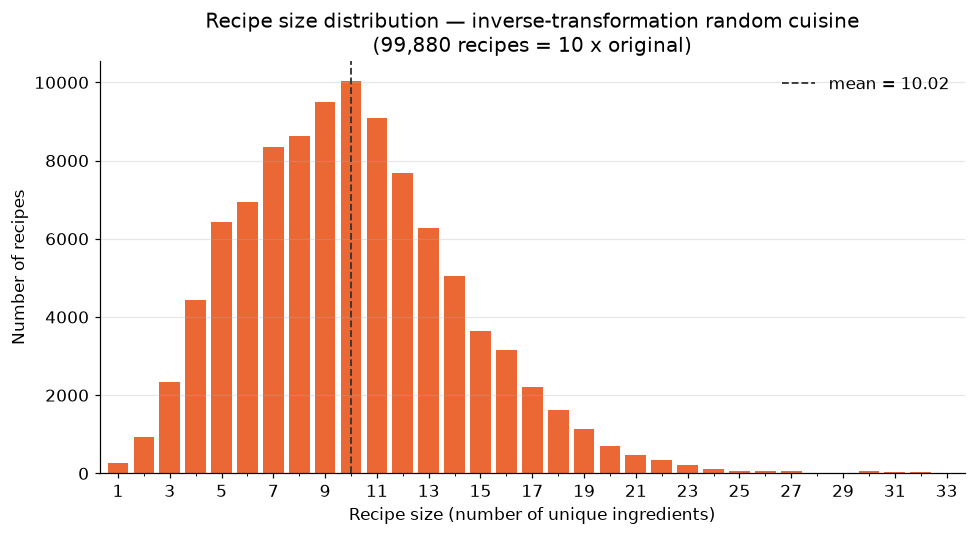

In [28]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(size_support, gen_counts, width=0.8, color=RAND_COLOR)
ax.axvline(gen_sizes.mean(), color="#333333", ls="--", lw=1.2, label=f"mean = {gen_sizes.mean():.2f}")
ax.set_xlabel("Recipe size (number of unique ingredients)")
ax.set_ylabel("Number of recipes")
ax.set_title(f"Recipe size distribution — inverse-transformation random cuisine\n"
             f"({N_GEN:,} recipes = {MULTIPLIER} x original)")
style_size_axis(ax)
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(OUT_DIR / "Q2b_inverse_transformation_recipe_size_distribution.png")
plt.show()

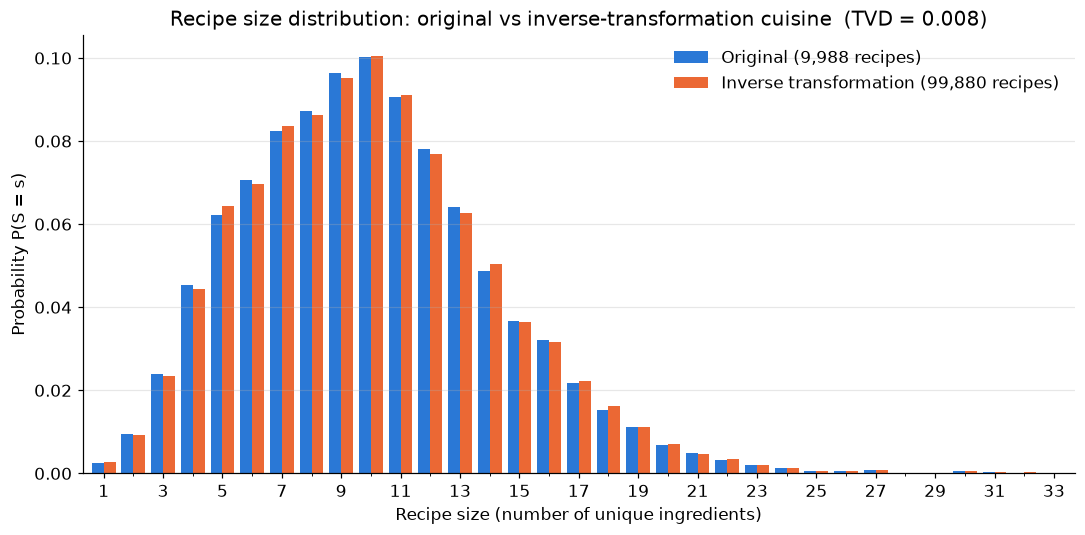

In [29]:
fig, ax = plt.subplots(figsize=(10, 5))
w = 0.4
ax.bar(size_support - w / 2, orig_pmf_full, width=w, color=ORIG_COLOR, label=f"Original ({N:,} recipes)")
ax.bar(size_support + w / 2, gen_pmf_full, width=w, color=RAND_COLOR,
       label=f"Inverse transformation ({N_GEN:,} recipes)")
ax.set_xlabel("Recipe size (number of unique ingredients)")
ax.set_ylabel("Probability P(S = s)")
ax.set_title(f"Recipe size distribution: original vs inverse-transformation cuisine  (TVD = {tvd:.3f})")
style_size_axis(ax)
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(OUT_DIR / "Q2b_original_vs_inverse_transformation.png")
plt.show()

In [30]:
pd.DataFrame({"Recipe_Size": size_support, "Original_Count": orig_counts, "Original_P": orig_pmf_full,
              "Generated_Count": gen_counts, "Generated_P": gen_pmf_full}) \
  .to_csv(OUT_DIR / "Q2b_recipe_size_pmf.csv", index=False)

if SAVE_RANDOM_CUISINES:
    rows = [(f"Random {j + 1}", name) for j, r in enumerate(gen_recipes) for name in ingredients[r]]
    pd.DataFrame(rows, columns=["Random_Recipe_ID", "Ingredient_Name"]) \
      .to_csv(OUT_DIR / "Q2b_random_cuisine.csv", index=False)

for f in ["Q2a_original_recipe_size_distribution.png", "Q2a_random_recipe_size_distribution.png",
          "Q2b_inverse_transformation_recipe_size_distribution.png",
          "Q2b_original_vs_inverse_transformation.png", "Q2b_cdf_inverse_transformation.png"]:
    assert (OUT_DIR / f).stat().st_size > 0, f
print("All Q2 plots saved.")

All Q2 plots saved.
